# 04 — Deep Learning Models: Load & Evaluate
Load pre-trained LSTM, STGCN, DCRNN checkpoints and evaluate on test data.

**Loading models** — loads saved `.pt` files from `results/models/`.

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))
import numpy as np
import torch
import matplotlib.pyplot as plt
from src import config
from src.config import set_seed, get_device
from src.data_loader import prepare_dataset
from src.graph_builder import build_graph
from src.evaluate import evaluate_predictions, print_results, compare_models
set_seed(42); device = get_device()

Using GPU: NVIDIA GeForce RTX 4060
GPU Memory: 8.2 GB


## 1. Prepare Data & Graph

In [2]:
DATASET = 'METR-LA'  # Change to 'PEMS-BAY' to evaluate that dataset
filepath = config.DATASETS[DATASET]['path']

data = prepare_dataset(filepath, batch_size=config.BATCH_SIZE)
mean, std = data['mean'], data['std']
num_sensors = data['splits']['train'][0].shape[2]

train_end = int(len(data['raw_data']) * config.TRAIN_RATIO)
graph = build_graph(data['raw_data'][:train_end],
                    sigma=config.GRAPH_SIGMA, epsilon=config.GRAPH_EPSILON)

test_X = torch.FloatTensor(data['splits']['test'][0]).to(device)
test_Y = data['splits']['test'][1]
print(f"Dataset: {DATASET} | Sensors: {num_sensors} | Test samples: {len(test_X)}")

Loading /home/anonymous/GraphNN/dataset/METR-LA.csv...
  Shape: (34272, 207) (timesteps × sensors)
  Time range: 2012-03-01 00:00:00 to 2012-06-27 23:55:00
  Missing values: 0 (0.00%)
  Zero values: 575302 (8.11%)
Handling missing values...
  After cleaning — NaN: 0, Zeros: 0
Creating sequences...
  Created 34249 sequences: X=(34249, 12, 207), Y=(34249, 12, 207)
Splitting data...
  train: 23974 samples
  val: 3425 samples
  test: 6850 samples
Building graph from sensor correlations...
  Adjacency matrix: 207x207
  Non-zero entries: 447 / 42849
  Sparsity: 98.96%
  Avg connections per node: 2.2
  Computing Chebyshev polynomials...
  Computing diffusion matrices...
Graph construction complete.

Dataset: METR-LA | Sensors: 207 | Test samples: 6850


## 2. Load & Evaluate LSTM

In [3]:
from src.models.lstm_model import LSTMModel

lstm = LSTMModel(num_sensors, config.SEQ_LEN, config.PRED_LEN,
                 config.LSTM_HIDDEN, config.LSTM_LAYERS, config.LSTM_DROPOUT).to(device)

ckpt = f'../results/models/lstm_{DATASET}_best.pt'
lstm.load_state_dict(torch.load(ckpt, weights_only=True, map_location=device))
lstm.eval()
print(f"Loaded: {ckpt}")
print(f"Parameters: {sum(p.numel() for p in lstm.parameters()):,}")

Loaded: ../results/models/lstm_METR-LA_best.pt
Parameters: 268,788


In [4]:
preds_lstm = []
with torch.no_grad():
    for i in range(0, len(test_X), config.BATCH_SIZE):
        batch = test_X[i:i+config.BATCH_SIZE]
        preds_lstm.append(lstm(batch).cpu().numpy())
preds_lstm = np.concatenate(preds_lstm)

r_lstm = evaluate_predictions(preds_lstm, test_Y, mean, std)
print_results(r_lstm, 'LSTM')


  Results: LSTM
  Horizon           MAE     RMSE  MAPE(%)
  ----------------------------------------
  15min          3.8433   6.7368    10.73
  30min          3.9097   6.8741    10.90
  60min          4.1370   7.2604    11.72
  overall        3.9440   6.9290    11.06



## 3. Load & Evaluate STGCN

In [5]:
from src.models.stgcn import STGCN

stgcn = STGCN(num_sensors, config.SEQ_LEN, config.PRED_LEN,
              K=config.STGCN_K, channels=config.STGCN_CHANNELS).to(device)

ckpt = f'../results/models/stgcn_{DATASET}_best.pt'
stgcn.load_state_dict(torch.load(ckpt, weights_only=True, map_location=device))
stgcn.eval()
print(f"Loaded: {ckpt}")
print(f"Parameters: {sum(p.numel() for p in stgcn.parameters()):,}")

Loaded: ../results/models/stgcn_METR-LA_best.pt
Parameters: 79,532


In [6]:
cheb = [torch.FloatTensor(p).to(device) for p in graph['cheb_polys']]
preds_stgcn = []
with torch.no_grad():
    for i in range(0, len(test_X), config.BATCH_SIZE):
        batch = test_X[i:i+config.BATCH_SIZE]
        preds_stgcn.append(stgcn(batch, cheb).cpu().numpy())
preds_stgcn = np.concatenate(preds_stgcn)

r_stgcn = evaluate_predictions(preds_stgcn, test_Y, mean, std)
print_results(r_stgcn, 'STGCN')


  Results: STGCN
  Horizon           MAE     RMSE  MAPE(%)
  ----------------------------------------
  15min          3.2607   5.5442     8.40
  30min          3.6289   6.2977     9.63
  60min          4.2317   7.3564    11.70
  overall        3.6587   6.3498     9.73



## 4. Load & Evaluate DCRNN

In [7]:
from src.models.dcrnn import DCRNN

n_sup = len(graph['diffusion_supports'])
dcrnn = DCRNN(num_sensors, n_sup, config.SEQ_LEN, config.PRED_LEN,
              config.DCRNN_HIDDEN, config.DCRNN_LAYERS).to(device)

ckpt = f'../results/models/dcrnn_{DATASET}_best.pt'
dcrnn.load_state_dict(torch.load(ckpt, weights_only=True, map_location=device))
dcrnn.eval()
print(f"Loaded: {ckpt}")
print(f"Parameters: {sum(p.numel() for p in dcrnn.parameters()):,}")

Loaded: ../results/models/dcrnn_METR-LA_best.pt
Parameters: 371,393


In [8]:
supports = [torch.FloatTensor(s).to(device) for s in graph['diffusion_supports']]
preds_dcrnn = []
with torch.no_grad():
    for i in range(0, len(test_X), config.BATCH_SIZE):
        batch = test_X[i:i+config.BATCH_SIZE]
        preds_dcrnn.append(dcrnn(batch, supports).cpu().numpy())
preds_dcrnn = np.concatenate(preds_dcrnn)

r_dcrnn = evaluate_predictions(preds_dcrnn, test_Y, mean, std)
print_results(r_dcrnn, 'DCRNN')


  Results: DCRNN
  Horizon           MAE     RMSE  MAPE(%)
  ----------------------------------------
  15min          2.8824   5.4787     7.55
  30min          3.5370   6.7788     9.72
  60min          4.4922   8.4128    12.99
  overall        3.5408   6.8201     9.76



## 5. Compare All Deep Models

In [9]:
all_results = {'LSTM': r_lstm, 'STGCN': r_stgcn, 'DCRNN': r_dcrnn}
compare_models(all_results, DATASET)


  MODEL COMPARISON — METR-LA

  --- 15MIN ---
  Model                          MAE     RMSE  MAPE(%)
  ----------------------------------------------------
  DCRNN                       2.8824   5.4787     7.55
  STGCN                       3.2607   5.5442     8.40
  LSTM                        3.8433   6.7368    10.73

  --- 30MIN ---
  Model                          MAE     RMSE  MAPE(%)
  ----------------------------------------------------
  DCRNN                       3.5370   6.7788     9.72
  STGCN                       3.6289   6.2977     9.63
  LSTM                        3.9097   6.8741    10.90

  --- 60MIN ---
  Model                          MAE     RMSE  MAPE(%)
  ----------------------------------------------------
  LSTM                        4.1370   7.2604    11.72
  STGCN                       4.2317   7.3564    11.70
  DCRNN                       4.4922   8.4128    12.99

  --- OVERALL ---
  Model                          MAE     RMSE  MAPE(%)
  ------------------

In [10]:
# GNN improvement over LSTM
lstm_mae = r_lstm['overall']['MAE']
for name, r in [('STGCN', r_stgcn), ('DCRNN', r_dcrnn)]:
    gnn_mae = r['overall']['MAE']
    imp = (lstm_mae - gnn_mae) / lstm_mae * 100
    print(f"{name} vs LSTM: {imp:+.1f}% MAE {'(better)' if imp > 0 else '(worse)'}")

STGCN vs LSTM: +7.2% MAE (better)
DCRNN vs LSTM: +10.2% MAE (better)


## 6. Prediction vs Ground Truth

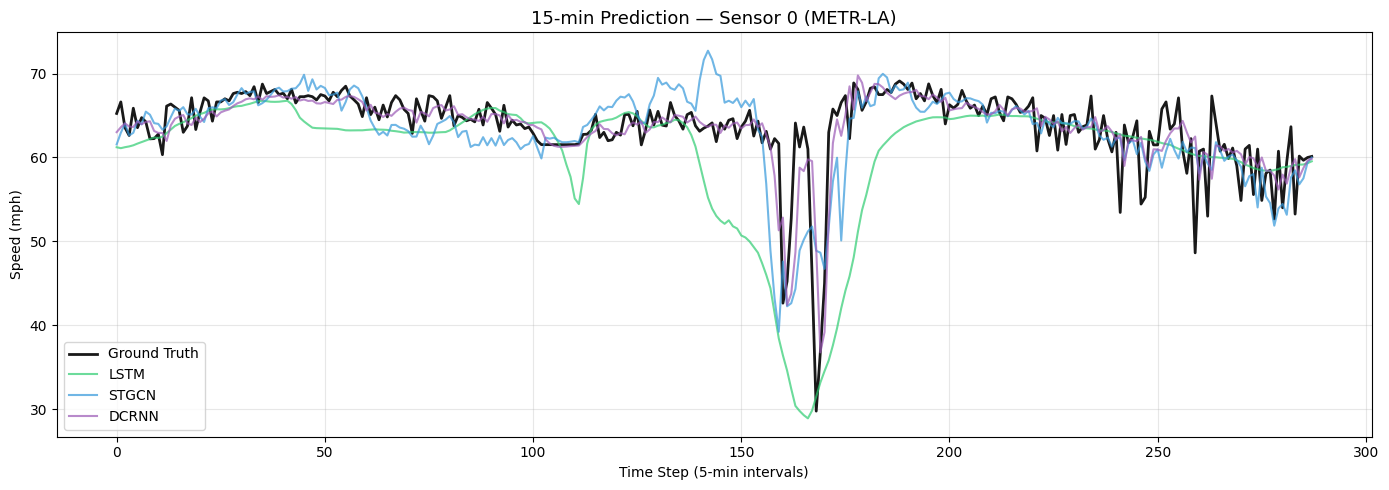

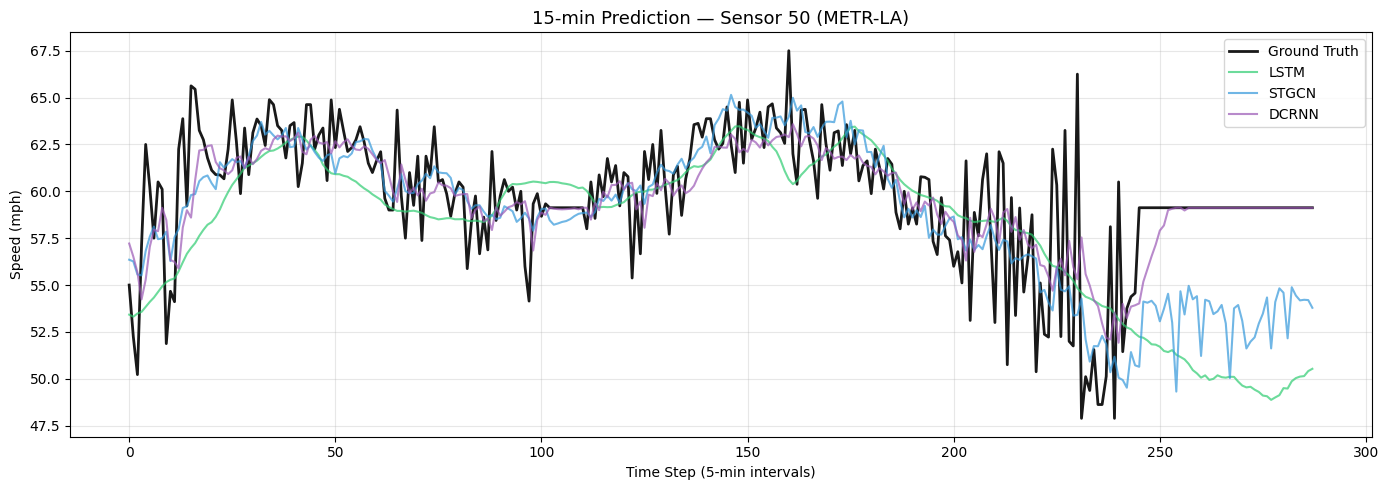

In [11]:
from src.data_loader import denormalize_data

all_preds = {'LSTM': preds_lstm, 'STGCN': preds_stgcn, 'DCRNN': preds_dcrnn}
colors = {'LSTM':'#2ecc71', 'STGCN':'#3498db', 'DCRNN':'#9b59b6'}

for sensor_idx in [0, 50]:
    if sensor_idx >= num_sensors:
        continue
    fig, ax = plt.subplots(figsize=(14, 5))
    T = 288  # 1 day

    gt_denorm = denormalize_data(test_Y[:T, 0, sensor_idx], mean[sensor_idx], std[sensor_idx])
    ax.plot(gt_denorm, color='black', linewidth=2, label='Ground Truth', alpha=0.9)

    for name, pred in all_preds.items():
        pred_denorm = denormalize_data(pred[:T, 0, sensor_idx], mean[sensor_idx], std[sensor_idx])
        ax.plot(pred_denorm, color=colors[name], linewidth=1.5, label=name, alpha=0.7)

    ax.set_title(f'15-min Prediction — Sensor {sensor_idx} ({DATASET})', fontsize=13)
    ax.set_xlabel('Time Step (5-min intervals)')
    ax.set_ylabel('Speed (mph)')
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'../results/plots/{DATASET}_pred_sensor{sensor_idx}.png', dpi=150, bbox_inches='tight')
    plt.show()

## 7. Per-Sensor Error Distribution

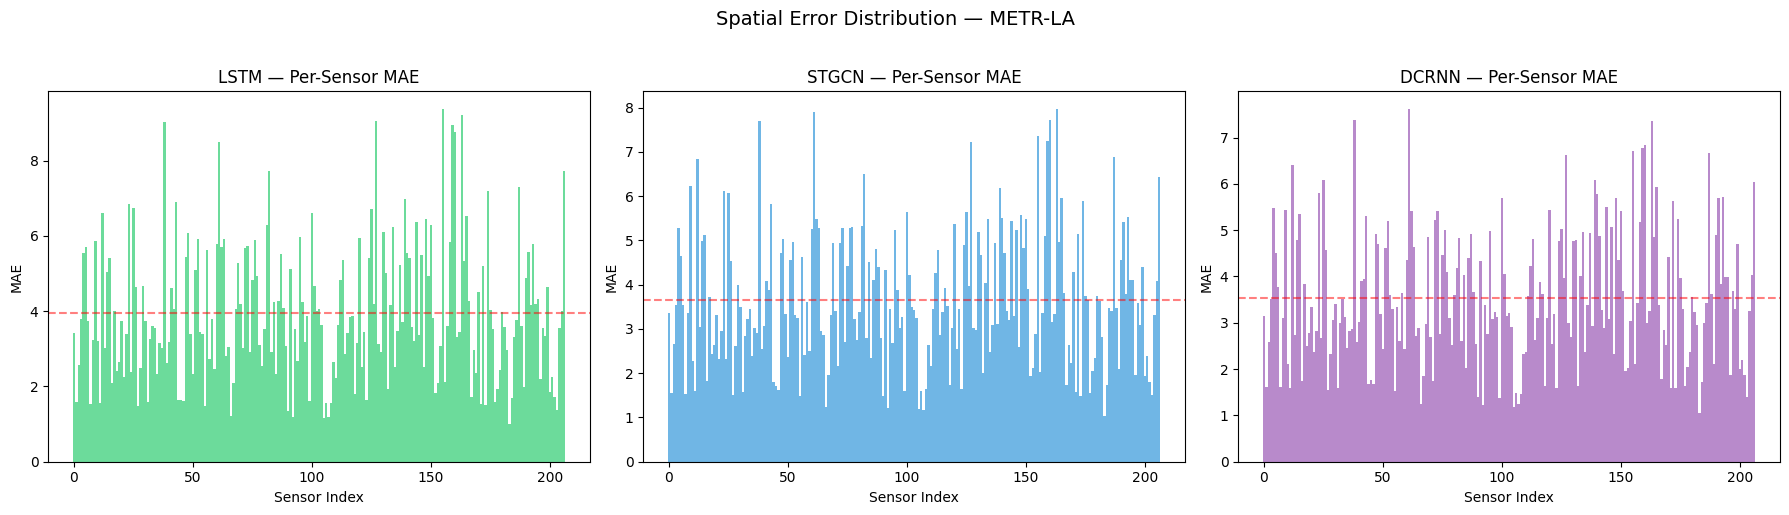

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, (name, pred) in enumerate(all_preds.items()):
    pred_d = pred * std[np.newaxis, np.newaxis, :] + mean[np.newaxis, np.newaxis, :]
    gt_d = test_Y * std[np.newaxis, np.newaxis, :] + mean[np.newaxis, np.newaxis, :]
    sensor_mae = np.mean(np.abs(pred_d - gt_d), axis=(0, 1))
    axes[idx].bar(range(len(sensor_mae)), sensor_mae, color=colors[name], alpha=0.7, width=1.0)
    axes[idx].set_title(f'{name} — Per-Sensor MAE', fontsize=12)
    axes[idx].set_xlabel('Sensor Index'); axes[idx].set_ylabel('MAE')
    axes[idx].axhline(sensor_mae.mean(), color='red', linestyle='--', alpha=0.5)
plt.suptitle(f'Spatial Error Distribution — {DATASET}', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'../results/plots/{DATASET}_spatial_error.png', dpi=150, bbox_inches='tight')
plt.show()